This shows the distibution of FiLM parameters(intiailized with identity ) , features before and after applying filM at Late MBC block 6 of finetuned best fold model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../../.."))

In [3]:
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gc.enable()
import torch

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../../../.."
data_csv    = os.path.join(main_folder, "data", "train.csv")
img_folder  = os.path.join(main_folder, "data", "train")

# EXPERIMENT-SPECIFIC
cfg_key  = "exp12_film"  # or other key
exp_name = "exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init_bn_affine_true"
out_dir  = os.path.join(main_folder, "outputs", "extra", exp_name)

df  = pd.read_csv(data_csv)
TARGET   = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

cfg = EXP_CONFIGS[cfg_key].copy()
cfg["name"] = exp_name

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Experiment:", cfg["name"])
print("Out dir:", out_dir)

Device: cuda
Experiment: exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init_bn_affine_true
Out dir: ../../../../outputs/extra/exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init_bn_affine_true


In [4]:
oof_path = os.path.join(out_dir, "oof_detail.csv")
df_oof   = pd.read_csv(oof_path)

fold_rmse_list = []
for f in range(1, cfg["n_splits"] + 1):
    sub  = df_oof[df_oof.fold == f]
    rmse = ((sub.ytrue - sub.oof_pred) ** 2).mean() ** 0.5
    fold_rmse_list.append((f, rmse))
    print(f"Fold {f} OOF RMSE: {rmse:.4f} (n={len(sub)})")

best_fold, best_rmse = min(fold_rmse_list, key=lambda x: x[1])
print(f"\nBest fold: {best_fold} (OOF RMSE={best_rmse:.4f})")

Fold 1 OOF RMSE: 19.8335 (n=1983)
Fold 2 OOF RMSE: 20.4920 (n=1983)
Fold 3 OOF RMSE: 19.3931 (n=1982)
Fold 4 OOF RMSE: 19.8961 (n=1982)
Fold 5 OOF RMSE: 19.9838 (n=1982)

Best fold: 3 (OOF RMSE=19.3931)


In [5]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
from src.data import build_transforms, ImageTabDataset

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
splits = list(kf.split(df))
tr_idx, val_idx = splits[best_fold - 1]

val_df = df.iloc[val_idx].reset_index(drop=True)
val_tf = build_transforms(cfg["img_size"], cfg["aug"], train=False)
val_ds = ImageTabDataset(val_df, img_folder, tab_cols, val_tf)

val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False,
    num_workers=16, pin_memory=True,
)

print("Val size (best fold):", len(val_ds))

Val size (best fold): 1982


In [6]:
from src.film import FiLMInternalModulation, FiLMExternalModulation

def build_best_model_internal(cfg, tab_cols, best_fold, out_dir, device):
    model = FiLMInternalModulation(
        backbone_name      = cfg["backbone"],
        img_size           = cfg["img_size"],
        tab_input_dim      = len(tab_cols),
        tab_hidden         = 64,
        film_start_idx     = 6,   # must match training (3 or 6 for mid/late)
        apply_to_all_after = False,
        head_hidden        = 256,
        pretrained         = False, #because weights are loaded from checkpoint
        use_bn_affine      = True, #
        freeze_backbone    = False,   # False or True doesn't matter as gradients are off and weights are loaded from checkpoint
        tab_encoder_capacity = "small",
        identity_init=True
    )
    ckpt_path = os.path.join(out_dir, f"model_fold{best_fold}.pt")
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state)
    model.to(device).eval()
    print("Loaded:", ckpt_path)
    return model

analysis_model = build_best_model_internal(cfg, tab_cols, best_fold, out_dir, device)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: ../../../../outputs/extra/exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init_bn_affine_true/model_fold3.pt


In [7]:
from src.film_analysis import collect_film_stats

gamma, beta, feat_before, feat_after = collect_film_stats(
    analysis_model, val_loader, device, max_batches=None
)
print("FiLM blocks found:", sorted(gamma.keys()))

FiLM blocks found: [6]


so we are modulating the feature maps of MBC Conv block 6 index, which has 320 channel size, so our gamma and beta should also have the same size as we apply gamma and beta per channel,

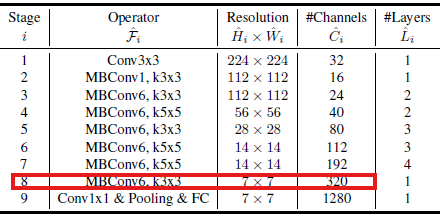



[FiLM] Block 6  — exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init_bn_affine_true
  gamma shape:       (1982, 320)
  beta shape:        (1982, 320)
  feat_before shape: (1982, 320, 8, 8)
  feat_after shape:  (1982, 320, 8, 8)


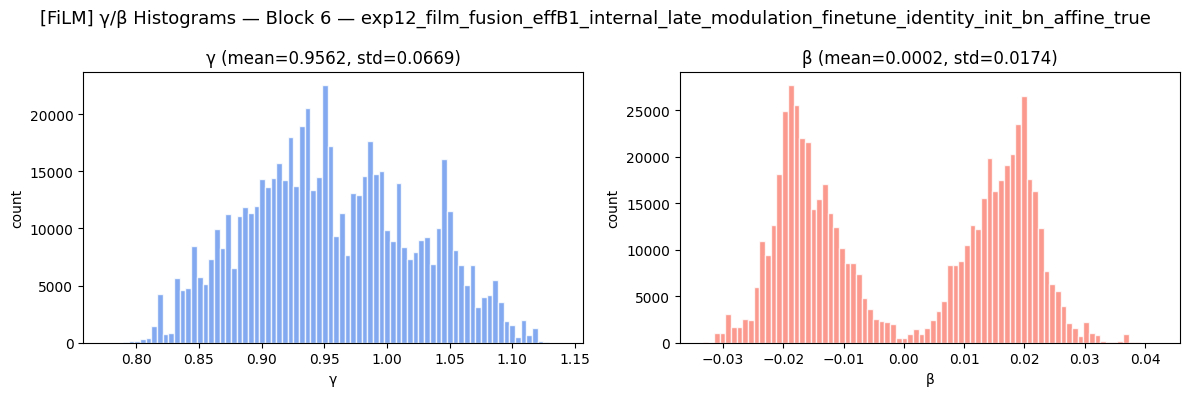

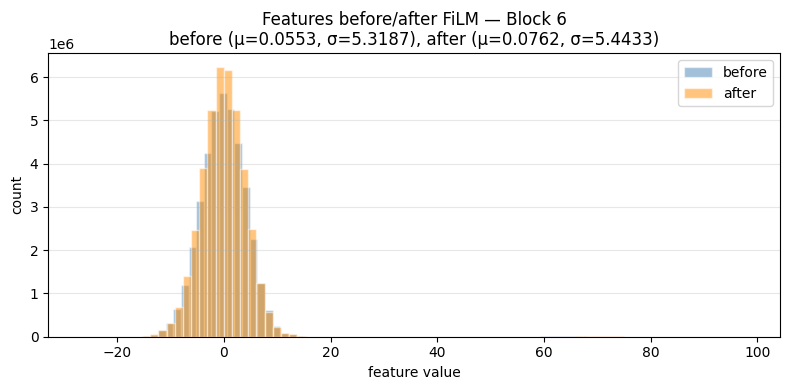

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,6,0,0,0,0,0.294579,0.274832,0.996915,-0.018838,0.019747
1,6,0,0,0,1,-0.115225,-0.133707,0.996915,-0.018838,0.018483
2,6,0,0,0,2,-0.253136,-0.271193,0.996915,-0.018838,0.018057
3,6,0,0,0,3,0.083198,0.064103,0.996915,-0.018838,0.019095
4,6,0,0,0,4,0.351225,0.331304,0.996915,-0.018838,0.019922
...,...,...,...,...,...,...,...,...,...,...
16380,6,0,255,7,4,3.537014,3.135519,0.880740,0.020330,0.401495
16381,6,0,255,7,5,3.677442,3.259199,0.880740,0.020330,0.418243
16382,6,0,255,7,6,3.766778,3.337881,0.880740,0.020330,0.428897
16383,6,0,255,7,7,4.639091,4.106162,0.880740,0.020330,0.532929


[FiLM] Block 6 global stats:
  L2 ||after - before|| = 2970.9993


,block_idx,which,min,max,mean,std
0,6,before,-26.728645,88.024643,0.055323,5.318659
1,6,after,-24.546457,98.002686,0.076214,5.443272


In [8]:
from src.film_analysis import analyze_film_per_block

analyze_film_per_block(
    gamma       = gamma,
    beta        = beta,
    feat_before = feat_before, #feature before FiLM 
    feat_after  = feat_after, # feature after FiLM 
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    n_table_rows = 16385, 
)

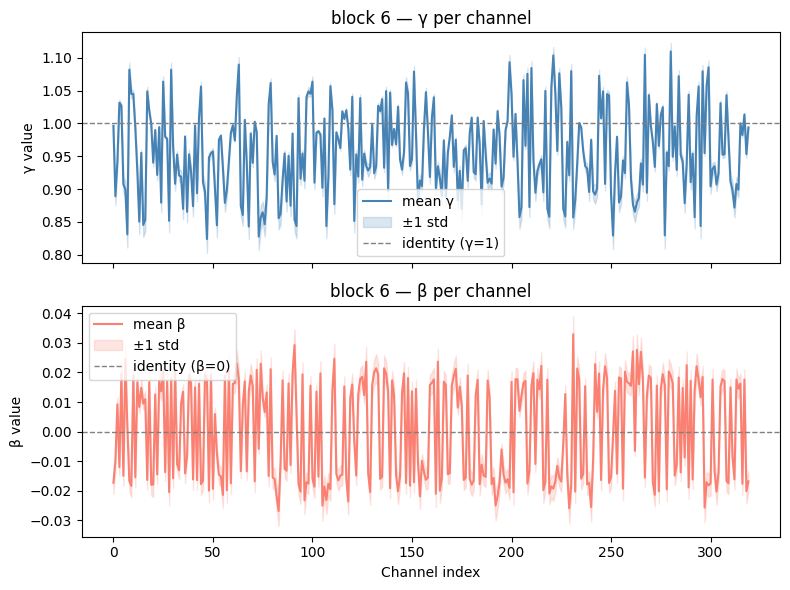

In [9]:
from src.film_analysis import plot_gamma_beta_per_channel

plot_gamma_beta_per_channel(
    gamma   = gamma,
    beta    = beta,
    exp_name = cfg["name"],
    out_dir  = out_dir,
)


[FiLM per-channel] Block 6 — exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init_bn_affine_true
  feat_before shape: (1982, 320, 8, 8)
  feat_after  shape: (1982, 320, 8, 8)


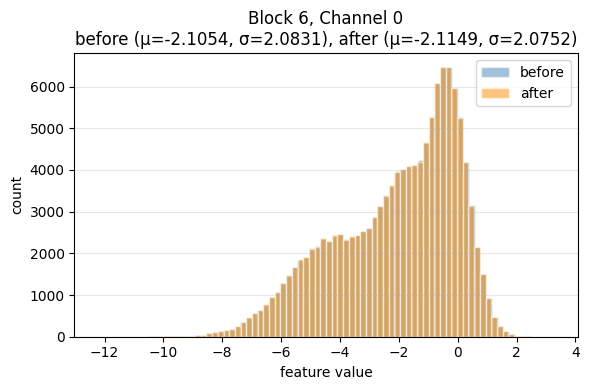

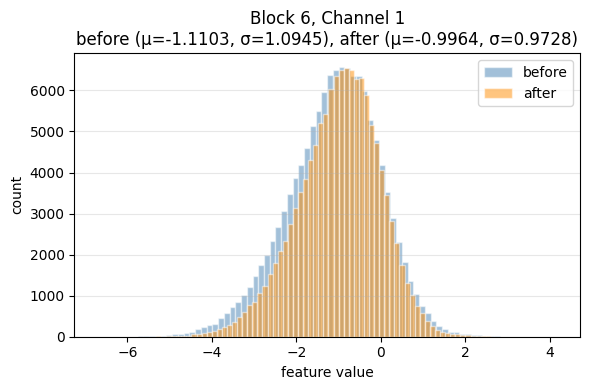

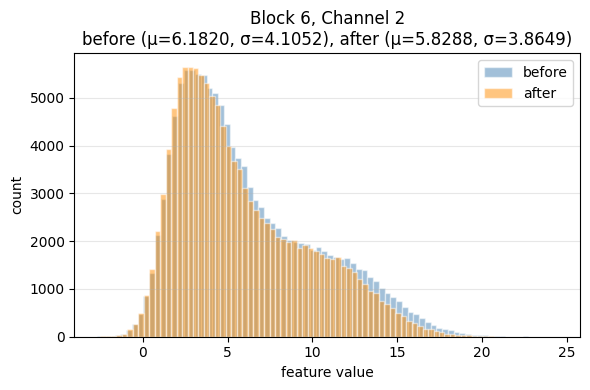

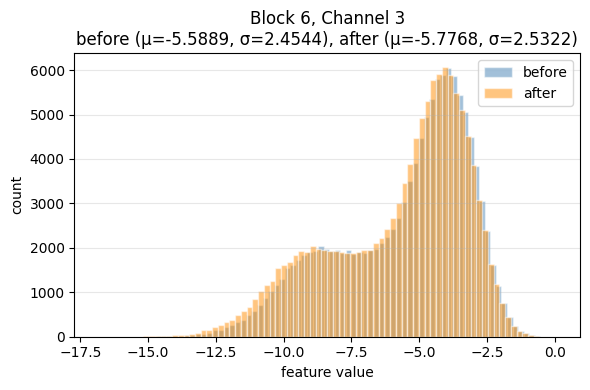

In [10]:
from src.film_analysis import analyze_film_per_channel
analyze_film_per_channel(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_channels = 4,   # e.g. first 4 channels
)


[FiLM per-sample] Block 6 — exp12_film_fusion_effB1_internal_late_modulation_finetune_identity_init_bn_affine_true
  feat_before shape: (1982, 320, 8, 8)
  feat_after  shape: (1982, 320, 8, 8)


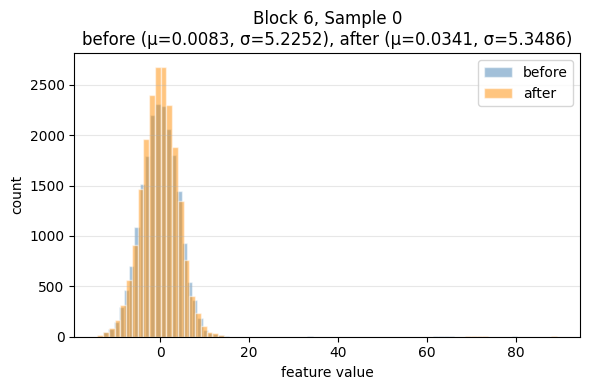

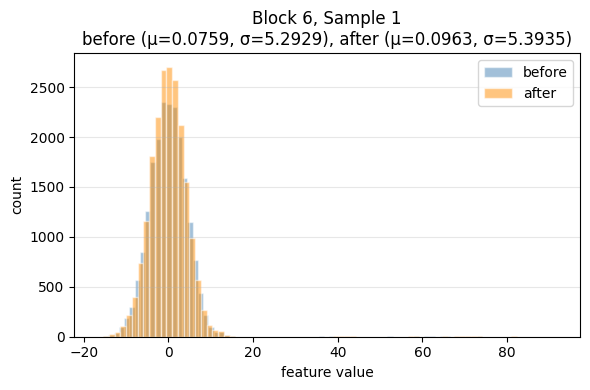

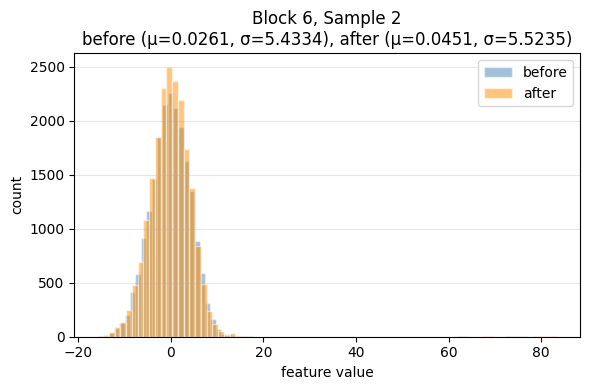

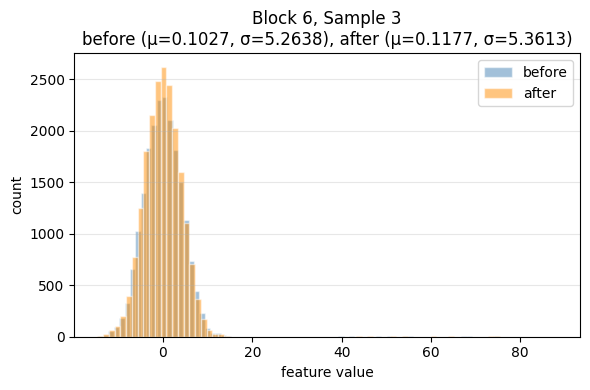

In [11]:
from src.film_analysis import analyze_film_per_sample
analyze_film_per_sample(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_samples = 4,   # e.g. first 4 samples
)